## 1.Prepare the data

### 1.1 Load the dataset

In [14]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 1.2 Separate target and features

In [15]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

### 1.3 Identify the feature types

In [24]:
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

print(numerical_cols)

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [25]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(categorical_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [26]:
print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 37
Categorical: 43


## 2.Split the data

### 2.1 Train/test split



In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1168, 80)
X_test shape: (292, 80)
y_train shape: (1168,)
y_test shape: (292,)


## 3.Decide which features to use

### 3.1 Numerical feature investigation

In [29]:
# Reconstruct training dataframe to analyze training set without leakage
train_df = X_train.assign(SalePrice=y_train)

# Calculate linear correlation with SalePrice for numerical features
correlation = train_df.corr(numeric_only=True)["SalePrice"]

# Sort correlation values in descending order
sorted_correlation = correlation.sort_values(ascending=False)

# Convert sorted_correlation to a list of (feature, correlation) tuples
sorted_correlation_list = list(sorted_correlation.items())

# Display the list
sorted_correlation_list

[('SalePrice', 1.0),
 ('OverallQual', 0.7855547508295233),
 ('GrLivArea', 0.6956519144967801),
 ('GarageCars', 0.6409907609784483),
 ('GarageArea', 0.624138884430746),
 ('TotalBsmtSF', 0.5977658678072638),
 ('1stFlrSF', 0.5878834001325344),
 ('FullBath', 0.5525460065335446),
 ('TotRmsAbvGrd', 0.5203884422148096),
 ('YearBuilt', 0.5165007897173519),
 ('YearRemodAdd', 0.5085928623194931),
 ('GarageYrBlt', 0.48035091204150354),
 ('MasVnrArea', 0.4591226943523084),
 ('Fireplaces', 0.4575492910719773),
 ('BsmtFinSF1', 0.35946011873579686),
 ('LotFrontage', 0.3300661478338092),
 ('WoodDeckSF', 0.3298430677096894),
 ('2ndFlrSF', 0.31403001861624963),
 ('OpenPorchSF', 0.2999691605590995),
 ('HalfBath', 0.2804808535046108),
 ('LotArea', 0.2662035157481018),
 ('BsmtFullBath', 0.2263459953646289),
 ('BsmtUnfSF', 0.22248700465738838),
 ('BedroomAbvGr', 0.15621072066050018),
 ('ScreenPorch', 0.1191721519973889),
 ('PoolArea', 0.11562969356780602),
 ('3SsnPorch', 0.05153159667710584),
 ('MoSold', 0.

#### Correlation with Target (SalePrice) - Relative

Filter and save numerical features with an absolute correlation $|r| \ge 0.05$ with `SalePrice`, excluding arbitrary IDs and noise features with $|r| < 0.05$.

In [30]:
# Filter numerical features with correlation >= 0.05
selected_corr_series = sorted_correlation[sorted_correlation >= 0.05]

# Exclude target variable 'SalePrice' and arbitrary identifier 'Id'
selected_corr_series = selected_corr_series.drop(labels=['SalePrice', 'Id'], errors='ignore')

# Create a detailed DataFrame table
selected_features_df = selected_corr_series.reset_index()
selected_features_df.columns = ['Feature', 'Correlation']

# Add Strength Tier classification
def classify_strength(r):
    if r >= 0.50:
        return 'Strong'
    elif r >= 0.30:
        return 'Moderate'
    else:
        return 'Weak'

selected_features_df['Strength'] = selected_features_df['Correlation'].apply(classify_strength)

# Save feature names list for downstream steps
selected_num_features = selected_features_df['Feature'].tolist()

# Display formatted DataFrame table
print(f"Correlation with Target (SalePrice) - Relative ({len(selected_features_df)} Features, Correlation >= 0.05):\n")
display(selected_features_df)

Correlation with Target (SalePrice) - Relative (26 Features, Correlation >= 0.05):



,Feature,Correlation,Strength
0,OverallQual,0.785555,Strong
1,GrLivArea,0.695652,Strong
2,GarageCars,0.640991,Strong
3,GarageArea,0.624139,Strong
4,TotalBsmtSF,0.597766,Strong
5,1stFlrSF,0.587883,Strong
6,FullBath,0.552546,Strong
7,TotRmsAbvGrd,0.520388,Strong
8,YearBuilt,0.516501,Strong
9,YearRemodAdd,0.508593,Strong


#### Correlation Matrix Heatmap

Visualize the correlation matrix for `SalePrice` and the selected numerical features (`selected_num_features`) to inspect feature-to-feature multicollinearity and overall correlation patterns.

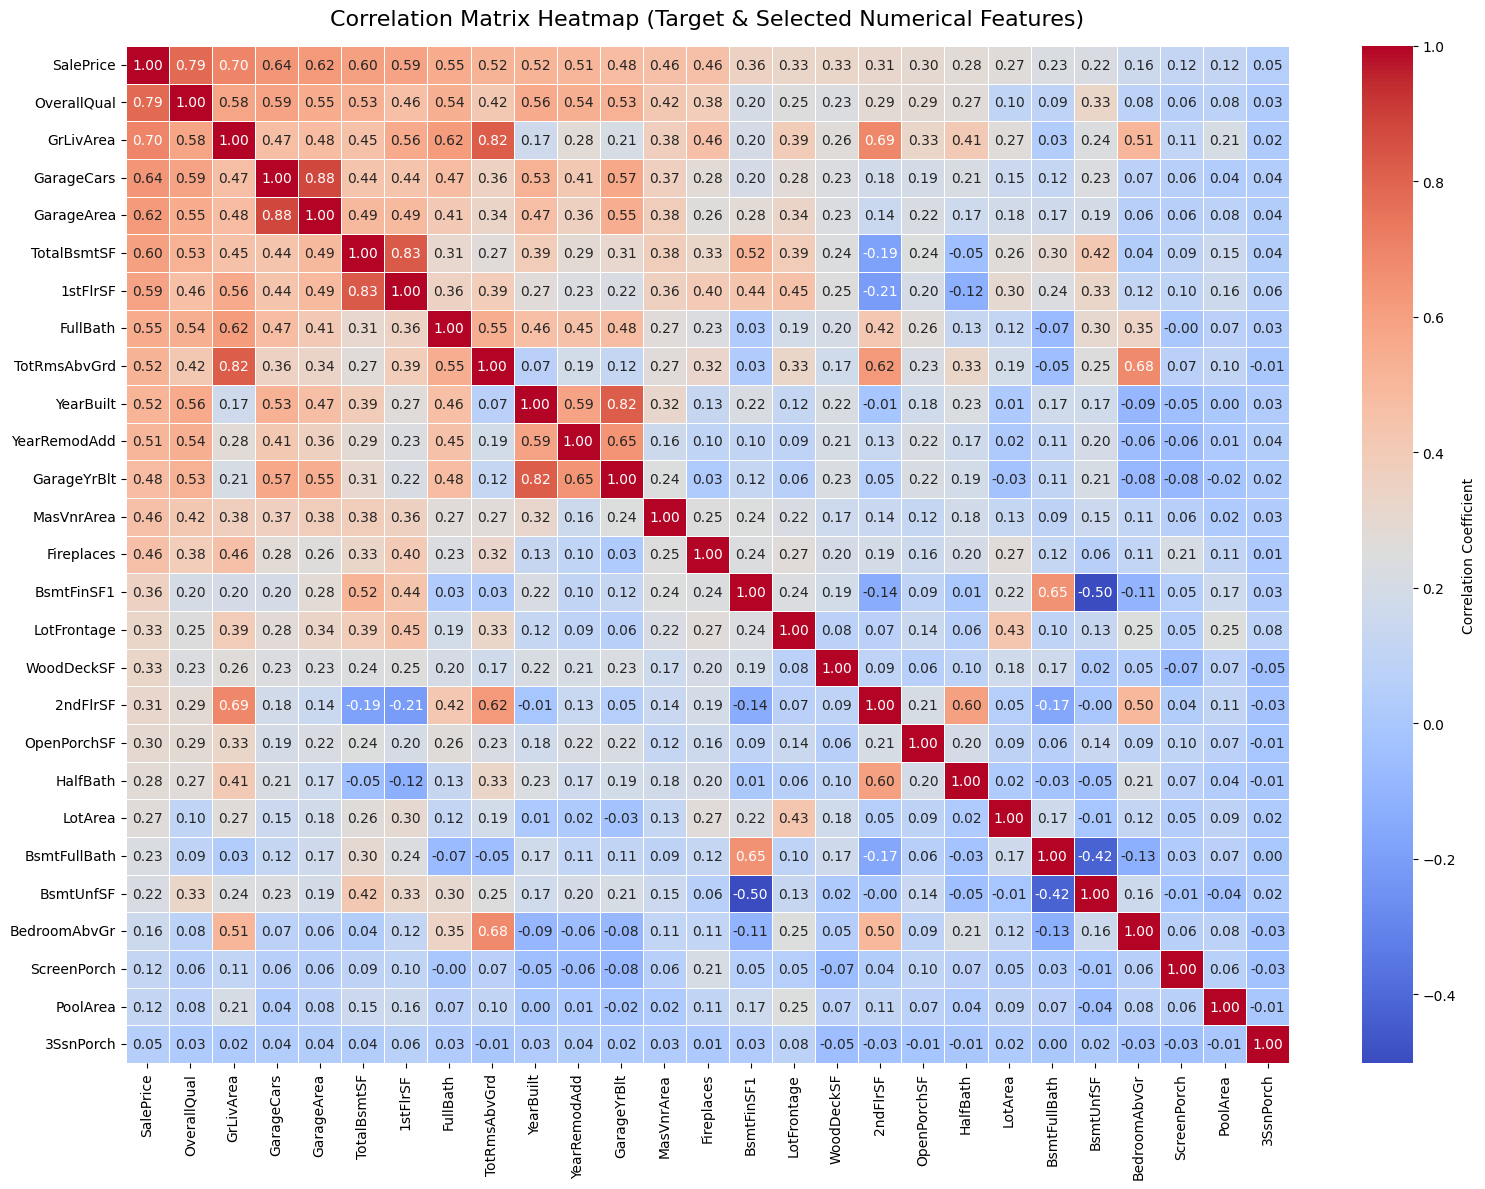

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create list of features including target 'SalePrice'
features_for_heatmap = ['SalePrice'] + selected_num_features

# Compute correlation matrix on training set
corr_matrix = train_df[features_for_heatmap].corr()

# Set up figure and plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    linewidths=0.5, 
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Matrix Heatmap (Target & Selected Numerical Features)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

### 3.2 Categorical feature investigation

#### 3.2.1 ANOVA for all categorical features

In [42]:
from scipy.stats import f_oneway
import pandas as pd

anova_results = []

for feature in categorical_features:
    
    # Combine feature and target
    temp = pd.DataFrame({
        feature: X_train[feature],
        'SalePrice': y_train
    })
    
    # Remove missing values for ANOVA
    temp = temp.dropna()
    
    # Create SalePrice groups for each category
    groups = [
        group['SalePrice'].values
        for _, group in temp.groupby(feature)
        if len(group) >= 2
    ]
    
    # ANOVA requires at least 2 groups
    if len(groups) >= 2:
        f_stat, p_value = f_oneway(*groups)
        
        anova_results.append({
            'Feature': feature,
            'F_Statistic': f_stat,
            'P_Value': p_value
        })

anova_df = pd.DataFrame(anova_results)

display(anova_df)

,Feature,F_Statistic,P_Value
0,MSZoning,31.026797,1.412720e-24
1,Street,0.279746,5.969682e-01
2,Alley,31.933074,2.995601e-07
3,LotShape,29.314662,2.841706e-18
4,LandContour,12.952648,2.514628e-08
5,LotConfig,6.971157,1.517764e-05
6,LandSlope,2.918212,5.442526e-02
7,Neighborhood,56.418980,5.761195e-170
8,Condition1,6.187235,3.962598e-07
9,Condition2,2.330147,7.278068e-02


#### 3.2.2 Rank the features

In [43]:
anova_df['Rank'] = (
    anova_df['F_Statistic']
    .rank(method='min', ascending=False)
    .astype(int)
)

anova_df = anova_df.sort_values(
    by='F_Statistic',
    ascending=False
).reset_index(drop=True)

display(anova_df)

,Feature,F_Statistic,P_Value,Rank
0,KitchenQual,332.403111,7.223574e-156,1
1,ExterQual,318.566812,5.695797e-151,2
2,BsmtQual,308.561969,1.710075e-146,3
3,GarageFinish,196.899421,7.872520e-74,4
4,HeatingQC,103.119709,3.405931e-59,5
5,CentralAir,89.825144,1.399942e-20,6
6,Foundation,77.154994,6.121416e-70,7
7,Neighborhood,56.418980,5.761195e-170,8
8,GarageType,55.506213,1.657969e-51,9
9,BsmtFinType1,52.949669,1.819590e-49,10


#### 3.2.3 Create your "useful features" list

In [46]:
selected_cat_features = anova_df[
    anova_df['P_Value'] < 0.05
][['Rank', 'Feature', 'F_Statistic', 'P_Value']]

display(selected_cat_features)

,Rank,Feature,F_Statistic,P_Value
0,1,KitchenQual,332.403111,7.223574e-156
1,2,ExterQual,318.566812,5.695797e-151
2,3,BsmtQual,308.561969,1.710075e-146
3,4,GarageFinish,196.899421,7.872520e-74
4,5,HeatingQC,103.119709,3.405931e-59
5,6,CentralAir,89.825144,1.399942e-20
6,7,Foundation,77.154994,6.121416e-70
7,8,Neighborhood,56.418980,5.761195e-170
8,9,GarageType,55.506213,1.657969e-51
9,10,BsmtFinType1,52.949669,1.819590e-49


In [50]:
selected_cat_features = anova_df[
    anova_df['P_Value'] < 0.05
]['Feature'].tolist()

print("Selected categorical features:")
print(selected_cat_features)

Selected categorical features:
['KitchenQual', 'ExterQual', 'BsmtQual', 'GarageFinish', 'HeatingQC', 'CentralAir', 'Foundation', 'Neighborhood', 'GarageType', 'BsmtFinType1', 'BsmtExposure', 'SaleCondition', 'PavedDrive', 'Alley', 'MSZoning', 'LotShape', 'MasVnrType', 'Electrical', 'Exterior1st', 'SaleType', 'Exterior2nd', 'FireplaceQu', 'HouseStyle', 'BsmtCond', 'RoofStyle', 'LandContour', 'BldgType', 'ExterCond', 'GarageQual', 'GarageCond', 'LotConfig', 'Condition1', 'RoofMatl', 'Heating', 'Fence', 'Functional']


In [51]:
print("Selected categorical features:")
print(selected_cat_features)

print("\nSelected numerical features:")
print(selected_num_features)

Selected categorical features:
['KitchenQual', 'ExterQual', 'BsmtQual', 'GarageFinish', 'HeatingQC', 'CentralAir', 'Foundation', 'Neighborhood', 'GarageType', 'BsmtFinType1', 'BsmtExposure', 'SaleCondition', 'PavedDrive', 'Alley', 'MSZoning', 'LotShape', 'MasVnrType', 'Electrical', 'Exterior1st', 'SaleType', 'Exterior2nd', 'FireplaceQu', 'HouseStyle', 'BsmtCond', 'RoofStyle', 'LandContour', 'BldgType', 'ExterCond', 'GarageQual', 'GarageCond', 'LotConfig', 'Condition1', 'RoofMatl', 'Heating', 'Fence', 'Functional']

Selected numerical features:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'HalfBath', 'LotArea', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'PoolArea', '3SsnPorch']


## 4.Handle missing values

#### 4.1 Re-check missing values

In [53]:
selected_features = selected_cat_features + selected_num_features

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

In [54]:
missing_train = (
    X_train_selected.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_train = missing_train[missing_train > 0]

display(missing_train)

,0
Alley,1094
Fence,935
MasVnrType,683
FireplaceQu,547
LotFrontage,217
GarageCond,64
GarageQual,64
GarageYrBlt,64
GarageType,64
GarageFinish,64


#### 4.2 Categorical absence

In [55]:
categorical_absence = [
    'Alley',
    'Fence',
    'MasVnrType',
    'FireplaceQu',
    'GarageCond',
    'GarageQual',
    'GarageType',
    'GarageFinish',
    'BsmtQual',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtCond'
]

In [56]:
for col in categorical_absence:
    X_train_selected[col] = X_train_selected[col].fillna('None')
    X_test_selected[col] = X_test_selected[col].fillna('None')

#### 4.3 Numerical absence

##### GarageYrBlt

In [57]:
X_train_selected['GarageYrBlt'] = (
    X_train_selected['GarageYrBlt'].fillna(0)
)

X_test_selected['GarageYrBlt'] = (
    X_test_selected['GarageYrBlt'].fillna(0)
)

##### MasVnrArea

In [58]:
X_train_selected['MasVnrArea'] = (
    X_train_selected['MasVnrArea'].fillna(0)
)

X_test_selected['MasVnrArea'] = (
    X_test_selected['MasVnrArea'].fillna(0)
)

##### LotFrontage

In [59]:
lotfrontage_median = X_train_selected['LotFrontage'].median()

X_train_selected['LotFrontage'] = (
    X_train_selected['LotFrontage']
    .fillna(lotfrontage_median)
)

X_test_selected['LotFrontage'] = (
    X_test_selected['LotFrontage']
    .fillna(lotfrontage_median)
)

print("LotFrontage median:", lotfrontage_median)

LotFrontage median: 70.0


##### Electrical

In [60]:
electrical_mode = X_train_selected['Electrical'].mode()[0]

X_train_selected['Electrical'] = (
    X_train_selected['Electrical']
    .fillna(electrical_mode)
)

X_test_selected['Electrical'] = (
    X_test_selected['Electrical']
    .fillna(electrical_mode)
)

print("Electrical mode:", electrical_mode)

Electrical mode: SBrkr


#### 4.4 Final Check

##### Train Split

In [61]:
missing_train_after = (
    X_train_selected.isnull()
    .sum()
)

missing_train_after = missing_train_after[
    missing_train_after > 0
]

print("Remaining missing values in X_train:")
display(missing_train_after)

Remaining missing values in X_train:


,0


##### Test Split

In [62]:
missing_test_after = (
    X_test_selected.isnull()
    .sum()
)

missing_test_after = missing_test_after[
    missing_test_after > 0
]

print("Remaining missing values in X_test:")
display(missing_test_after)

Remaining missing values in X_test:


,0
